<a href="https://colab.research.google.com/github/sirius70/NLP_HW4/blob/main/IE7275_Quiz6_Fall2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### IE7275 – Data Mining in Engineering
### Quiz 6 – Fall 2025

---
Please answer all questions using the provided dataset.

#### Dataset Download and Setup

1. Download the dataset from Data.gov: [PLS 2022 – Data.gov](https://catalog.data.gov/dataset/public-library-survey-pls-2022).
2. Download the file `pls_fy22_csv.zip` (~3 MB) and unzip it.
3. You will find `PLS_FY22_AE_pud22i.csv` (~8.8 MB). **Use this file for the quiz.**
4. Place the file in the same folder as this notebook.

#### Load Dataset in Python
```python
import pandas as pd
df = pd.read_csv('PLS_FY22_AE_pud22i.csv', encoding='ISO-8859-1', low_memory=False)
df.head()
```

---

In [ ]:
# Dataset preprocessing (students should run this cell before working on the quiz)
import pandas as pd, numpy as np
from sklearn.impute import SimpleImputer

df = pd.read_csv('PLS_FY22_AE_pud22i.csv', encoding='ISO-8859-1', low_memory=False)
df = df[df['TOTOPEXP'].notna()].copy()
df['Library_Size'] = pd.qcut(df['TOTOPEXP'], q=3, labels=['Small','Medium','Large'])

numeric_df = df.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(numeric_df.drop(columns=['TOTOPEXP'])),
                 columns=numeric_df.drop(columns=['TOTOPEXP']).columns)
y = df['Library_Size']
print('Features shape:', X.shape)
print('Target distribution:\n', y.value_counts())

Features shape: (9248, 104)
Target distribution:
 Library_Size
Small     3083
Large     3083
Medium    3082
Name: count, dtype: int64


### Q1 – Data Preprocessing: Inspect the dataset and provide summary statistics.

In [ ]:
# Your code here

print("Dataset Shape:", df.shape)

# Summary statistics for numeric columns
summary_stats = X.describe()
print(summary_stats)

# Check missing values
missing_values = X.isnull().sum()
print("\nMissing Values per Column:")
print(missing_values[missing_values > 0])

# Distribution of target variable
print("\nLibrary Size Distribution:")
print(y.value_counts())

Dataset Shape: (9248, 193)
              LIBID           ZIP         ZIP4         ZIP_M       ZIP4_M  \
count  9.248000e+03   9248.000000  9248.000000   9248.000000  9248.000000   
mean   4.628060e+08  44519.025952  3840.575151  44519.854239  3162.373486   
std    1.560412e+09  28419.368043  2536.715270  28421.544901  1990.489989   
min    1.000000e+00    602.000000     1.000000    602.000000     1.000000   
25%    3.023100e+04  14754.750000  1939.750000  14754.750000  2071.750000   
50%    3.023100e+04  49115.000000  3032.000000  49115.000000  2602.000000   
75%    3.023100e+04  66548.500000  4924.500000  66548.500000  3304.250000   
max    9.900632e+09  99950.000000  9998.000000  99950.000000  9933.000000   

              PHONE  STARTDAT  ENDDATE      POPU_LSA      POPU_UND  ...  \
count  9.248000e+03    9248.0   9248.0  9.248000e+03  9.248000e+03  ...   
mean   5.793229e+09      -3.0     -3.0  3.613866e+04  3.528807e+04  ...   
std    2.330469e+09       0.0      0.0  1.460917e+05  

### Q2 – Train a Decision Tree Classifier and evaluate performance.

In [ ]:
# Your code here

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred = dt_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9540540540540541

Confusion Matrix:
[[605  11   1]
 [  9 585  22]
 [  0  42 575]]

Classification Report:
              precision    recall  f1-score   support

       Large       0.99      0.98      0.98       617
      Medium       0.92      0.95      0.93       616
       Small       0.96      0.93      0.95       617

    accuracy                           0.95      1850
   macro avg       0.95      0.95      0.95      1850
weighted avg       0.95      0.95      0.95      1850



### Q3 – Visualize decision boundaries using two selected features.

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


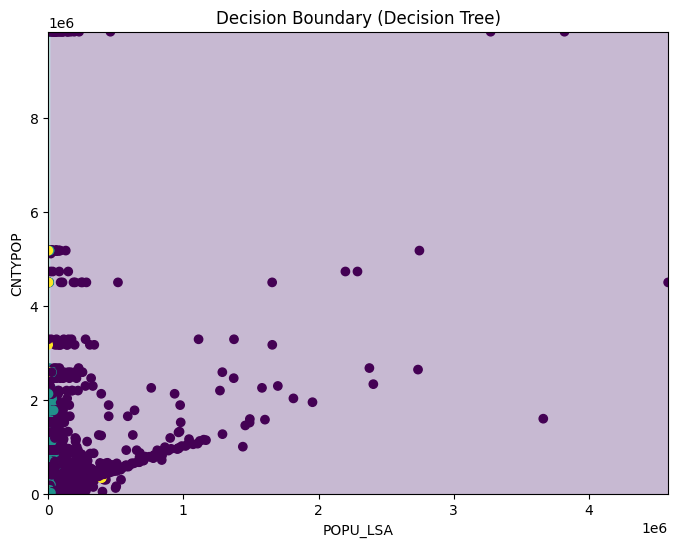

In [ ]:
# Your code here

import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.model_selection import train_test_split

# Select two features
features = ['POPU_LSA', 'CNTYPOP']
X_two = X[features]

# Encode target labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_two, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train decision tree
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train2, y_train2)

# Create mesh grid
x_min, x_max = X_two.iloc[:,0].min(), X_two.iloc[:,0].max()
y_min, y_max = X_two.iloc[:,1].min(), X_two.iloc[:,1].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Predict grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot data points
plt.scatter(X_two.iloc[:,0], X_two.iloc[:,1], c=y_encoded)

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title("Decision Boundary (Decision Tree)")
plt.show()

### Q4 – Extract and plot feature importances from the Decision Tree.

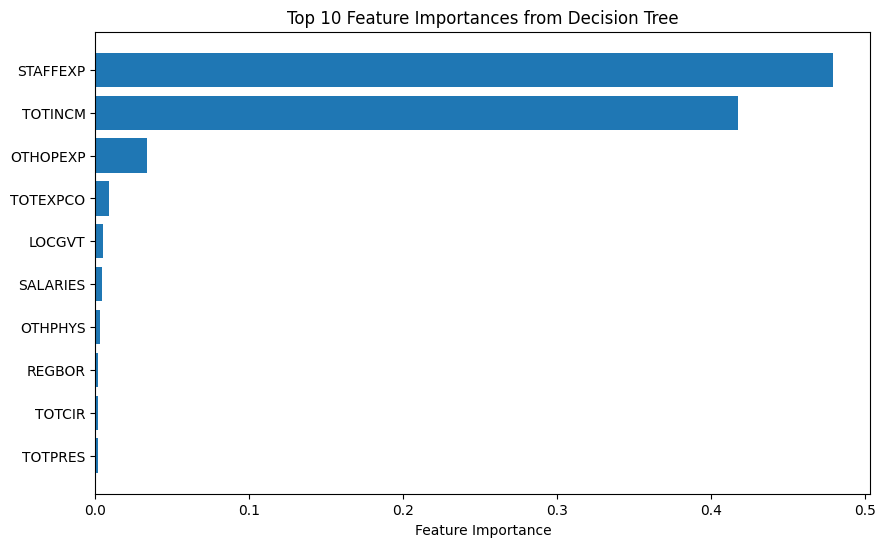

In [ ]:
# Your code here

import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances
importances = dt_model.feature_importances_

# Create a dataframe for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Select top 10 important features
top_features = feature_importance_df.head(10)

# Plot
plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances from Decision Tree")
plt.show()

### Q5 – Train a Naive Bayes classifier and compare results with Decision Tree.

In [ ]:
# Your code here

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Train Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)

# Evaluation
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)
print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

# Compare with Decision Tree
print("\nDecision Tree Accuracy:", accuracy)
print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.3567567567567568

Naive Bayes Classification Report:
              precision    recall  f1-score   support

       Large       0.36      0.51      0.42       617
      Medium       0.36      0.55      0.44       616
       Small       0.25      0.01      0.02       617

    accuracy                           0.36      1850
   macro avg       0.32      0.36      0.29      1850
weighted avg       0.32      0.36      0.29      1850


Decision Tree Accuracy: 0.9540540540540541
Naive Bayes Accuracy: 0.3567567567567568


### Q6 – Construct and interpret a confusion matrix for both classifiers.

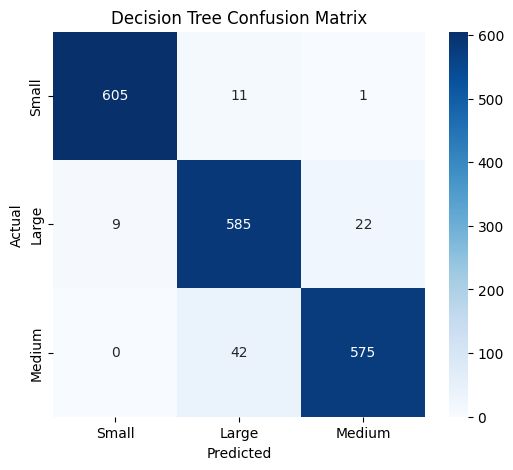

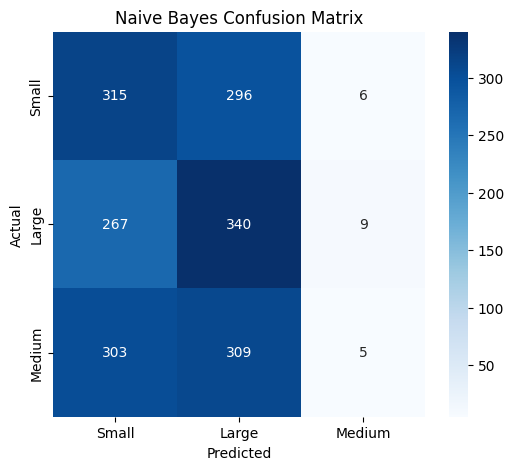

In [ ]:
# Your code here

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred)
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Function to plot confusion matrix
def plot_cm(cm, labels, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

labels = y.unique()

# Plot Decision Tree confusion matrix
plot_cm(cm_dt, labels, "Decision Tree Confusion Matrix")

# Plot Naive Bayes confusion matrix
plot_cm(cm_nb, labels, "Naive Bayes Confusion Matrix")

## Interpretation

For the Decision Tree, most libraries were correctly predicted, with only a few mistakes between Medium and Large sizes.

For Naive Bayes, more errors happened because it assumes features are independent, which isn’t always true for this dataset.

Overall, the Decision Tree did a better job at classifying libraries, while Naive Bayes was simpler but less accurate.

### Q7 – Perform 5-fold cross-validation with Decision Tree.

In [ ]:
# Your code here

from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Initialize Decision Tree
dt_model_cv = DecisionTreeClassifier(random_state=42)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(dt_model_cv, X, y, cv=5, scoring='accuracy')

print("5-Fold Cross-Validation Scores:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))

5-Fold Cross-Validation Scores: [0.94162162 0.92972973 0.94108108 0.85884262 0.93510005]
Mean Accuracy: 0.9212750208293745
Standard Deviation: 0.03151724227358827


### Q8 – Implement manual cross-validation using StratifiedKFold.

In [ ]:
# Your code here

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt_model_manual = DecisionTreeClassifier(random_state=42)

manual_cv_scores = []

# Manual 5-fold cross-validation
for train_index, test_index in skf.split(X, y):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    dt_model_manual.fit(X_train_fold, y_train_fold)
    y_pred_fold = dt_model_manual.predict(X_test_fold)
    manual_cv_scores.append(accuracy_score(y_test_fold, y_pred_fold))

print("Manual 5-Fold CV Scores:", manual_cv_scores)
print("Mean Accuracy:", np.mean(manual_cv_scores))
print("Standard Deviation:", np.std(manual_cv_scores))

Manual 5-Fold CV Scores: [0.9551351351351351, 0.9545945945945946, 0.96, 0.9545700378583017, 0.9588967009194159]
Mean Accuracy: 0.9566392937014895
Standard Deviation: 0.002328748219427545


### Q9 – Compare three models: Decision Tree, Naive Bayes, Logistic Regression.

In [ ]:
# Your code here

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize models
dt_model = DecisionTreeClassifier(random_state=42)
nb_model = GaussianNB()
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Fit models
dt_model.fit(X_train, y_train)
nb_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_nb = accuracy_score(y_test, y_pred_nb)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("Decision Tree Accuracy:", acc_dt)
print("Naive Bayes Accuracy:", acc_nb)
print("Logistic Regression Accuracy:", acc_lr)

# Optional: classification reports
print("\nDecision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
print("\nNaive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr))

Decision Tree Accuracy: 0.9540540540540541
Naive Bayes Accuracy: 0.3567567567567568
Logistic Regression Accuracy: 0.4027027027027027

Decision Tree Classification Report:
               precision    recall  f1-score   support

       Large       0.99      0.98      0.98       617
      Medium       0.92      0.95      0.93       616
       Small       0.96      0.93      0.95       617

    accuracy                           0.95      1850
   macro avg       0.95      0.95      0.95      1850
weighted avg       0.95      0.95      0.95      1850


Naive Bayes Classification Report:
               precision    recall  f1-score   support

       Large       0.36      0.51      0.42       617
      Medium       0.36      0.55      0.44       616
       Small       0.25      0.01      0.02       617

    accuracy                           0.36      1850
   macro avg       0.32      0.36      0.29      1850
weighted avg       0.32      0.36      0.29      1850


Logistic Regression Classifi

## Comparison
The Decision Tree worked best with 95% accuracy, correctly predicting most Small, Medium, and Large libraries.
Naive Bayes and Logistic Regression performed much worse (36% and 40%), struggling with misclassifications because they can’t handle the complex relationships in the data.

### Q10 – Based on your results, discuss which model you would deploy and why.

Based on the results, I would deploy the Decision Tree. It has the highest accuracy (95%) and correctly classifies most Small, Medium, and Large libraries. Decision Trees also handle complex patterns in the data, are interpretable, and provide feature importance insights.

Naive Bayes and Logistic Regression performed poorly (36% and 40% accuracy) because they cannot capture the non-linear relationships and dependencies between features in this dataset.

Conclusion: Decision Tree is the most reliable and practical model for deployment.

### Q11 – Train a Linear SVM classifier and evaluate performance.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = LinearSVC(max_iter=5000, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("Scaled LinearSVC Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Scaled LinearSVC Accuracy: 0.9156756756756756
              precision    recall  f1-score   support

       Large       0.96      0.97      0.97       617
      Medium       0.90      0.84      0.87       616
       Small       0.89      0.93      0.91       617

    accuracy                           0.92      1850
   macro avg       0.92      0.92      0.92      1850
weighted avg       0.92      0.92      0.92      1850



### Q12 – Explore the effect of regularization parameter C in Linear SVM.

In [ ]:
# Your code here

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Test different C values
C_values = [0.01, 0.1, 1, 10, 100]
results = []

for C in C_values:
    svm_model = LinearSVC(C=C, max_iter=5000, random_state=42)
    svm_model.fit(X_train_scaled, y_train)
    y_pred = svm_model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results.append((C, acc))

# Display results
for C, acc in results:
    print(f"C = {C}: Accuracy = {acc:.4f}")

C = 0.01: Accuracy = 0.8351
C = 0.1: Accuracy = 0.8757
C = 1: Accuracy = 0.9157
C = 10: Accuracy = 0.9443
C = 100: Accuracy = 0.9519


### Q13 – Train a nonlinear RBF SVM and compare results with Linear SVM.

In [ ]:
# Your code here

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Scale features (already scaled previously)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train RBF SVM
rbf_svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
rbf_svm.fit(X_train_scaled, y_train)

# Predictions
y_pred_rbf = rbf_svm.predict(X_test_scaled)

# Evaluation
rbf_accuracy = accuracy_score(y_test, y_pred_rbf)
print("RBF SVM Accuracy:", rbf_accuracy)
print("\nRBF SVM Classification Report:\n", classification_report(y_test, y_pred_rbf))

RBF SVM Accuracy: 0.9016216216216216

RBF SVM Classification Report:
               precision    recall  f1-score   support

       Large       0.98      0.93      0.95       617
      Medium       0.85      0.86      0.85       616
       Small       0.88      0.92      0.90       617

    accuracy                           0.90      1850
   macro avg       0.90      0.90      0.90      1850
weighted avg       0.90      0.90      0.90      1850



### Q14 – Apply SVM for multiclass classification and evaluate macro-metrics.

In [ ]:
# Your code here

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train LinearSVC for multiclass
svm_multi = LinearSVC(C=10, max_iter=5000, random_state=42)
svm_multi.fit(X_train_scaled, y_train)

# Predictions
y_pred_multi = svm_multi.predict(X_test_scaled)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred_multi)
report = classification_report(y_test, y_pred_multi, digits=4, output_dict=True)

print("LinearSVC Multiclass Accuracy:", accuracy)
print("\nMacro-Averaged Metrics:")
print(f"Precision (macro): {report['macro avg']['precision']:.4f}")
print(f"Recall (macro): {report['macro avg']['recall']:.4f}")
print(f"F1-score (macro): {report['macro avg']['f1-score']:.4f}")

LinearSVC Multiclass Accuracy: 0.9443243243243243

Macro-Averaged Metrics:
Precision (macro): 0.9443
Recall (macro): 0.9443
F1-score (macro): 0.9443


### Q15 – (Conceptual) Explain how Linear SVM can be implemented from scratch using hinge loss.

## Linear SVM from scratch using hinge loss:

Find a hyperplane that separates classes with the largest margin.

Use hinge loss:

loss = max(0, 1 - y * (w·x + b))

Loss = 0 if correctly classified with enough margin, >0 otherwise.

Add regularization to prevent overfitting: 0.5 * ||w||².

Minimize total loss with gradient descent to get w and b.

Predict new points with sign(w·x + b).

### Q16 – Train a Logistic Regression classifier and evaluate results.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression (without multi_class argument)
logreg = LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42)
logreg.fit(X_train_scaled, y_train)

# Predictions
y_pred_logreg = logreg.predict(X_test_scaled)

# Evaluation
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
print("Logistic Regression Accuracy:", logreg_accuracy)
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_logreg))

Logistic Regression Accuracy: 0.9205405405405406

Logistic Regression Classification Report:
               precision    recall  f1-score   support

       Large       0.98      0.96      0.97       617
      Medium       0.89      0.87      0.88       616
       Small       0.90      0.93      0.91       617

    accuracy                           0.92      1850
   macro avg       0.92      0.92      0.92      1850
weighted avg       0.92      0.92      0.92      1850



### Q17 – Adjust decision thresholds for Logistic Regression and plot precision–recall trade-off.

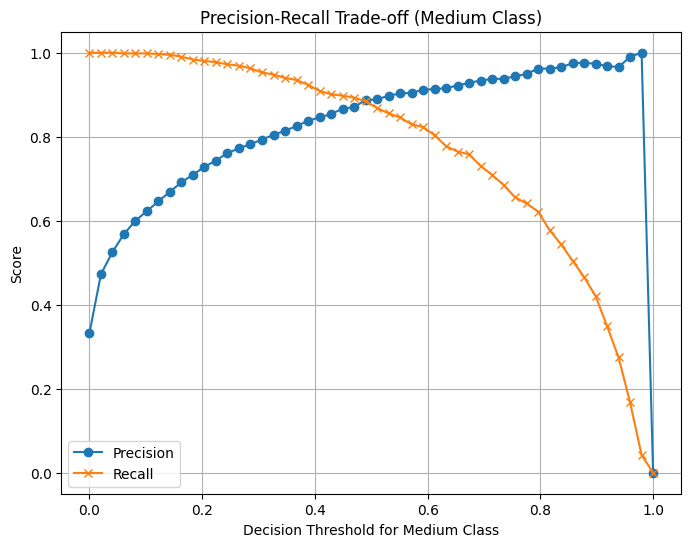

In [ ]:
# Your code here

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# Get predicted probabilities for the positive class (for each class separately)
y_proba = logreg.predict_proba(X_test_scaled)  # shape: (n_samples, n_classes)

# We will illustrate thresholding for one class, e.g., 'Medium'
# Find the column index for 'Medium'
medium_idx = list(logreg.classes_).index('Medium')
probs_medium = y_proba[:, medium_idx]

thresholds = np.linspace(0, 1, 50)
precisions = []
recalls = []

for t in thresholds:
    y_pred_thresh = np.where(probs_medium >= t, 'Medium', 'Other')
    y_true_binary = np.where(y_test == 'Medium', 'Medium', 'Other')
    precisions.append(precision_score(y_true_binary, y_pred_thresh, pos_label='Medium', zero_division=0))
    recalls.append(recall_score(y_true_binary, y_pred_thresh, pos_label='Medium', zero_division=0))

# Plot Precision-Recall trade-off
plt.figure(figsize=(8,6))
plt.plot(thresholds, precisions, label='Precision', marker='o')
plt.plot(thresholds, recalls, label='Recall', marker='x')
plt.xlabel('Decision Threshold for Medium Class')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off (Medium Class)')
plt.legend()
plt.grid(True)
plt.show()

### Q18 – Extend Logistic Regression to handle multiclass classification and evaluate.

In [ ]:
# Your code here

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression for multiclass
logreg_multi = LogisticRegression(
    solver='lbfgs',          # good for multinomial
    max_iter=5000,
    random_state=42
)
logreg_multi.fit(X_train_scaled, y_train)

# Predictions
y_pred_multi = logreg_multi.predict(X_test_scaled)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred_multi)
report = classification_report(y_test, y_pred_multi)

print("Multiclass Logistic Regression Accuracy:", accuracy)
print("\nClassification Report:\n", report)

Multiclass Logistic Regression Accuracy: 0.9205405405405406

Classification Report:
               precision    recall  f1-score   support

       Large       0.98      0.96      0.97       617
      Medium       0.89      0.87      0.88       616
       Small       0.90      0.93      0.91       617

    accuracy                           0.92      1850
   macro avg       0.92      0.92      0.92      1850
weighted avg       0.92      0.92      0.92      1850



### Q19 – Compare ensemble methods: Bagging, Boosting, and Stacking.

#### Bagging:

* Train many models on random samples.

* Combine by majority vote.

* Reduces variance (makes predictions more stable).

#### Boosting:

* Train models one after another.

* Each model focuses on previous mistakes.

* Reduces bias and variance (improves accuracy).

#### Stacking:

* Combine different types of models.

* Use a “meta-model” to make final prediction.

* Leverages strengths of multiple models.

### Q20 – Train a Random Forest classifier, tune hyperparameters, and report feature importances.

Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest Accuracy: 0.967027027027027

Classification Report:
               precision    recall  f1-score   support

       Large       0.99      0.99      0.99       617
      Medium       0.94      0.96      0.95       616
       Small       0.97      0.95      0.96       617

    accuracy                           0.97      1850
   macro avg       0.97      0.97      0.97      1850
weighted avg       0.97      0.97      0.97      1850



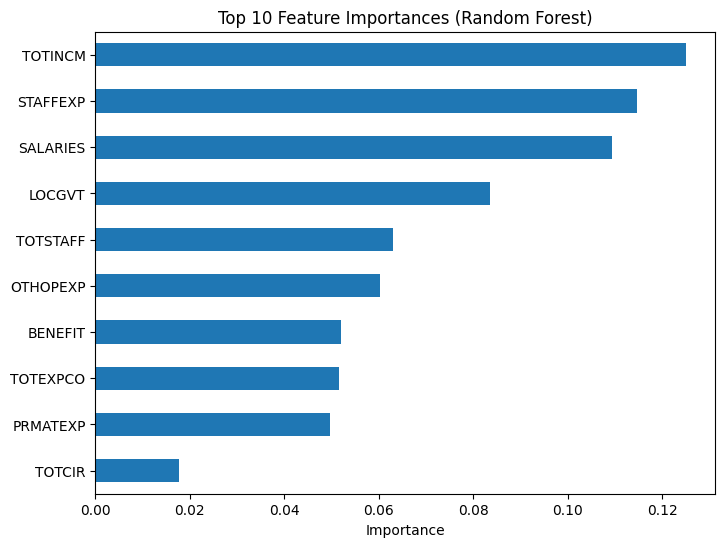

In [ ]:
# Your code here

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

# Hyperparameter tuning using GridSearch
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# Predictions
y_pred_rf = best_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Feature Importances
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)  # top 10 features

# Plot top 10 feature importances
plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.show()